In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All packages loaded!")
print("Pandas version:", pd.__version__)

All packages loaded!
Pandas version: 2.3.1


In [2]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (1470, 35)
Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


=== Dataset Info ===
Total Employees: 1470
Attrition Rate: 16.1%
Departments: ['Sales' 'Research & Development' 'Human Resources']

Missing Values: 0


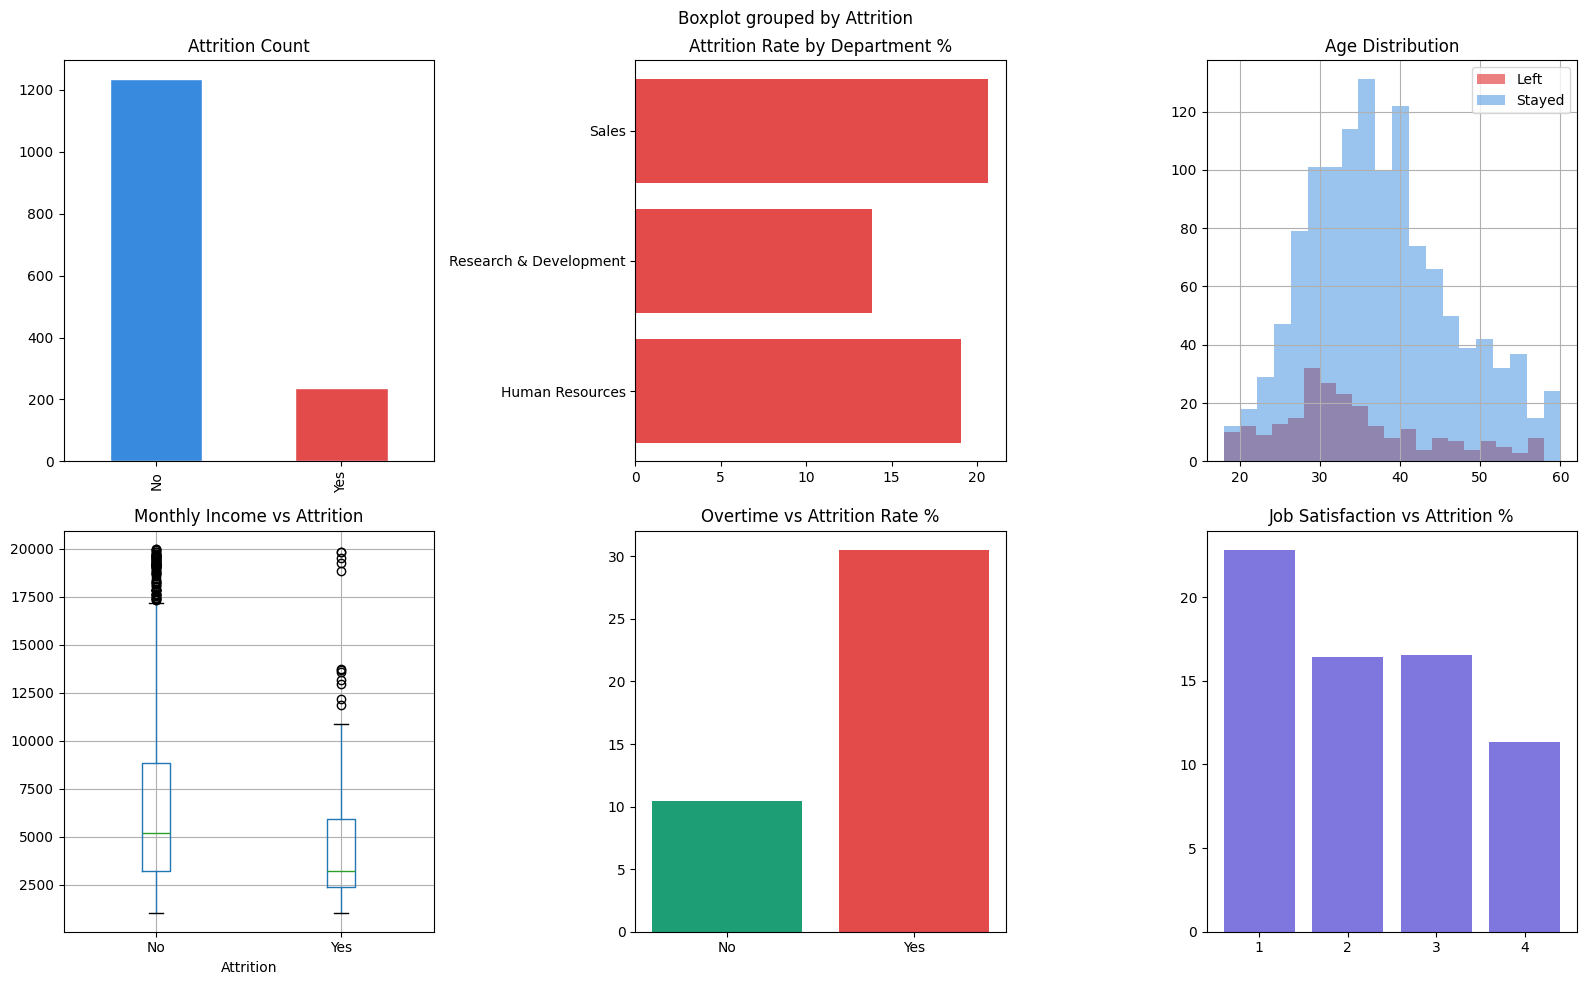

EDA Dashboard saved!


In [3]:
# Basic info
print("=== Dataset Info ===")
print(f"Total Employees: {len(df)}")
print(f"Attrition Rate: {round(df['Attrition'].value_counts(normalize=True)['Yes']*100, 1)}%")
print(f"Departments: {df['Department'].unique()}")
print(f"\nMissing Values: {df.isnull().sum().sum()}")

# Attrition distribution
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('IBM HR Attrition - EDA Dashboard', fontsize=16, fontweight='bold')

# Chart 1 - Attrition count
df['Attrition'].value_counts().plot(kind='bar', ax=axes[0,0], 
    color=['#378ADD','#E24B4A'], edgecolor='white')
axes[0,0].set_title('Attrition Count')
axes[0,0].set_xlabel('')

# Chart 2 - Attrition by Department
dept = df.groupby('Department')['Attrition'].apply(
    lambda x: (x=='Yes').sum()/len(x)*100).reset_index()
axes[0,1].barh(dept['Department'], dept['Attrition'], color='#E24B4A')
axes[0,1].set_title('Attrition Rate by Department %')

# Chart 3 - Age distribution
df[df['Attrition']=='Yes']['Age'].hist(ax=axes[0,2], bins=20, 
    color='#E24B4A', alpha=0.7, label='Left')
df[df['Attrition']=='No']['Age'].hist(ax=axes[0,2], bins=20, 
    color='#378ADD', alpha=0.5, label='Stayed')
axes[0,2].set_title('Age Distribution')
axes[0,2].legend()

# Chart 4 - Monthly Income vs Attrition
df.boxplot(column='MonthlyIncome', by='Attrition', ax=axes[1,0])
axes[1,0].set_title('Monthly Income vs Attrition')
plt.sca(axes[1,0])
plt.title('Monthly Income vs Attrition')

# Chart 5 - Overtime vs Attrition
ot = df.groupby('OverTime')['Attrition'].apply(
    lambda x: (x=='Yes').sum()/len(x)*100).reset_index()
axes[1,1].bar(ot['OverTime'], ot['Attrition'], color=['#1D9E75','#E24B4A'])
axes[1,1].set_title('Overtime vs Attrition Rate %')

# Chart 6 - Job Satisfaction vs Attrition
js = df.groupby('JobSatisfaction')['Attrition'].apply(
    lambda x: (x=='Yes').sum()/len(x)*100).reset_index()
axes[1,2].bar(js['JobSatisfaction'], js['Attrition'], color='#7F77DD')
axes[1,2].set_title('Job Satisfaction vs Attrition %')

plt.tight_layout()
plt.savefig('eda_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA Dashboard saved!")

In [ ]:
%pip install xgboost

In [7]:
%pip install xgboost
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb

# Step 1 - Encode categorical columns
df_ml = df.copy()

le = LabelEncoder()
cat_cols = df_ml.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

print("Encoding done!")
print(f"Features: {df_ml.shape[1]-1}")

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Note: you may need to restart the kernel to use updated packages.
Encoding done!
Features: 34


In [8]:
# Step 2 - Train/Test split
X = df_ml.drop('Attrition', axis=1)
y = df_ml['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Step 3 - Train XGBoost model
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

# Step 4 - Evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {round(accuracy*100, 1)}%")
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Stayed','Left']))

Model Accuracy: 86.4%

=== Classification Report ===
              precision    recall  f1-score   support

      Stayed       0.87      0.98      0.92       247
        Left       0.71      0.26      0.38        47

    accuracy                           0.86       294
   macro avg       0.79      0.62      0.65       294
weighted avg       0.85      0.86      0.84       294



  Using cached shap-0.51.0-cp313-cp313-win_amd64.whl.metadata (26 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.65.1-cp313-cp313-win_amd64.whl.metadata (3.0 kB)
  Using cached llvmlite-0.47.0-cp313-cp313-win_amd64.whl.metadata (5.1 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached shap-0.51.0-cp313-cp313-win_amd64.whl (555 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached llvmlite-0.47.0-cp313-cp313-win_amd64.whl (38.1 MB)
Using cached numba-0.65.1-cp313-cp313-win_amd64.whl (2.8 MB)

   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------------------------------- 1/5 [llvmlite]
   -

c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


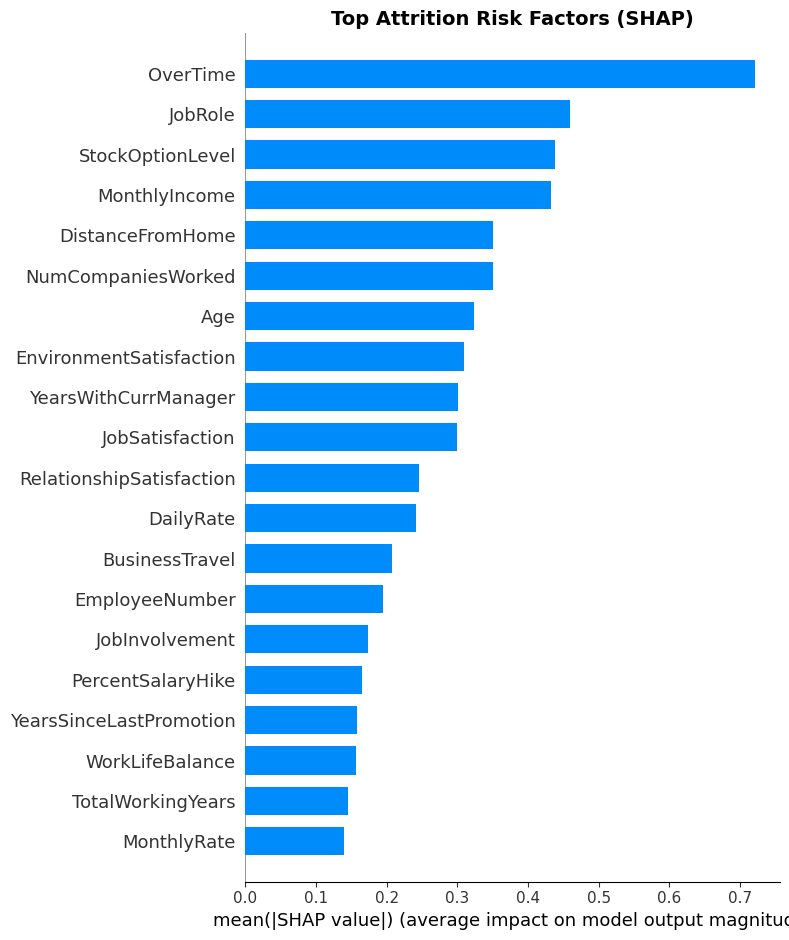

SHAP plot saved!
Predictions exported!
High Risk Employees: 193
Medium Risk Employees: 31
Low Risk Employees: 1237


In [10]:
%pip install shap
import shap

# Step 5 - SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# SHAP Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('Top Attrition Risk Factors (SHAP)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP plot saved!")

# Step 6 - Export predictions to CSV
df_export = df.copy()
df_export['AttritionRisk'] = model.predict_proba(
    df_ml.drop('Attrition', axis=1))[:, 1]
df_export['AttritionRisk%'] = (df_export['AttritionRisk'] * 100).round(1)
df_export['RiskLevel'] = pd.cut(
    df_export['AttritionRisk%'],
    bins=[0, 30, 60, 100],
    labels=['Low', 'Medium', 'High']
)

df_export.to_csv('hr_attrition_predictions.csv', index=False)
print(f"Predictions exported!")
print(f"High Risk Employees: {(df_export['RiskLevel']=='High').sum()}")
print(f"Medium Risk Employees: {(df_export['RiskLevel']=='Medium').sum()}")
print(f"Low Risk Employees: {(df_export['RiskLevel']=='Low').sum()}")

Note: you may need to restart the kernel to use updated packages.
=== HR ATTRITION PREDICTION SYSTEM ===

📊 USE CASE 1: New Employee Attrition Risk
---------------------------------------------
Employee Profile: 28yr Sales Rep, Single, OverTime, Low Income
Attrition Risk Score: 98.1%
Risk Level: 🔴 HIGH RISK

💰 USE CASE 2: Salary Raise What-If Simulation
---------------------------------------------


c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_label.py:11

Salary Raise %  Avg Risk Score  High Risk Count
           +0%            15.2              193
          +10%            14.2              176
          +20%            13.7              164
          +30%            13.4              158
          +40%            13.1              152
          +50%            13.0              148


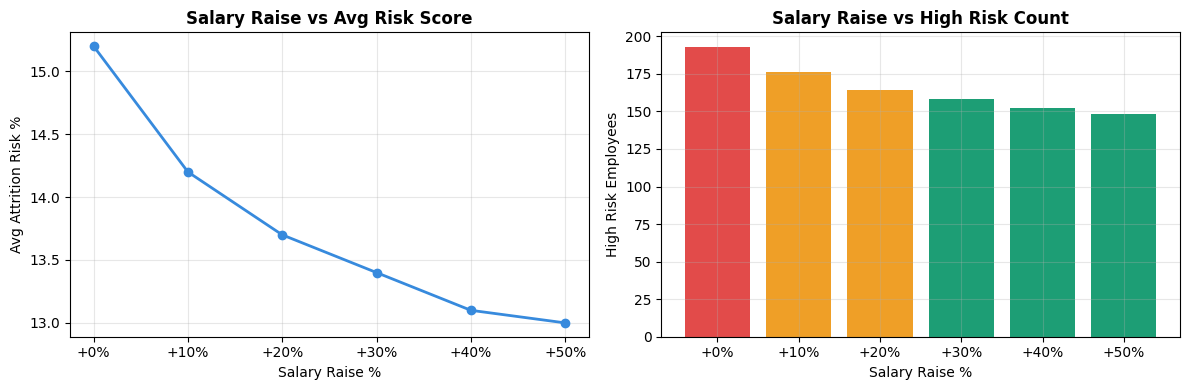


⏱ USE CASE 3: Overtime Ban Impact Simulation
---------------------------------------------
BEFORE Overtime Ban:
  Avg Risk Score    : 15.2%
  High Risk Employees: 193

AFTER Overtime Ban:
  Avg Risk Score    : 10.6%
  High Risk Employees: 109

✅ Risk Reduction   : 4.6%
✅ Employees Saved  : 84
✅ Cost Saved ($)   : $3,277,477


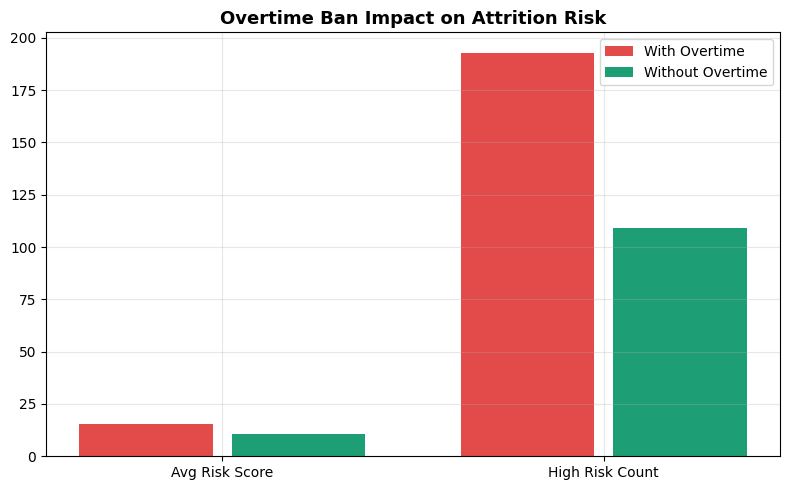


🎯 All 3 simulations complete!
📁 Charts saved: salary_simulation.png, overtime_impact.png


In [13]:
%pip install ipywidgets
import ipywidgets as widgets
from IPython.display import display, clear_output

print("=== HR ATTRITION PREDICTION SYSTEM ===\n")

# ============================================
# USE CASE 1 - New Employee Risk Prediction
# ============================================
print("📊 USE CASE 1: New Employee Attrition Risk")
print("-" * 45)

new_employee = {
    'Age': 28,
    'BusinessTravel': 'Travel_Frequently',
    'DailyRate': 500,
    'Department': 'Sales',
    'DistanceFromHome': 25,
    'Education': 3,
    'EducationField': 'Life Sciences',
    'EnvironmentSatisfaction': 2,
    'Gender': 'Male',
    'HourlyRate': 60,
    'JobInvolvement': 2,
    'JobLevel': 1,
    'JobRole': 'Sales Representative',
    'JobSatisfaction': 2,
    'MaritalStatus': 'Single',
    'MonthlyIncome': 3000,
    'MonthlyRate': 15000,
    'NumCompaniesWorked': 3,
    'OverTime': 'Yes',
    'PercentSalaryHike': 11,
    'PerformanceRating': 3,
    'RelationshipSatisfaction': 2,
    'StockOptionLevel': 0,
    'TotalWorkingYears': 5,
    'TrainingTimesLastYear': 2,
    'WorkLifeBalance': 2,
    'YearsAtCompany': 1,
    'YearsInCurrentRole': 1,
    'YearsSinceLastPromotion': 1,
    'YearsWithCurrManager': 1
}

# Encode new employee
new_df = pd.DataFrame([new_employee])
for col in cat_cols:
    if col != 'Attrition' and col in new_df.columns:
        combined = pd.concat([df[[col]], new_df[[col]]], ignore_index=True)
        new_df[col] = le.fit_transform(combined)[len(df):]

# Remove non-feature columns
drop_cols = ['Attrition', 'EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
new_features = new_df.drop([c for c in drop_cols if c in new_df.columns], axis=1)
new_features = new_features.reindex(columns=X.columns, fill_value=0)

risk_score = model.predict_proba(new_features)[0][1] * 100
risk_level = "🔴 HIGH RISK" if risk_score >= 60 else "🟡 MEDIUM RISK" if risk_score >= 30 else "🟢 LOW RISK"

print(f"Employee Profile: 28yr Sales Rep, Single, OverTime, Low Income")
print(f"Attrition Risk Score: {risk_score:.1f}%")
print(f"Risk Level: {risk_level}")

# ============================================
# USE CASE 2 - Salary Raise What-If
# ============================================
print("\n💰 USE CASE 2: Salary Raise What-If Simulation")
print("-" * 45)

df_sim = df_ml.copy()
results = []

for raise_pct in [0, 10, 20, 30, 40, 50]:
    df_temp = df_sim.copy()
    df_temp['MonthlyIncome'] = df_temp['MonthlyIncome'] * (1 + raise_pct/100)
    features_temp = df_temp.drop('Attrition', axis=1)
    risks = model.predict_proba(features_temp)[:, 1]
    avg_risk = risks.mean() * 100
    high_risk_count = (risks >= 0.6).sum()
    results.append({
        'Salary Raise %': f"+{raise_pct}%",
        'Avg Risk Score': round(avg_risk, 1),
        'High Risk Count': high_risk_count
    })

sim_df = pd.DataFrame(results)
print(sim_df.to_string(index=False))

# Plot salary simulation
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot([r['Salary Raise %'] for r in results], 
           [r['Avg Risk Score'] for r in results], 
           marker='o', color='#378ADD', linewidth=2)
ax[0].set_title('Salary Raise vs Avg Risk Score', fontweight='bold')
ax[0].set_xlabel('Salary Raise %')
ax[0].set_ylabel('Avg Attrition Risk %')
ax[0].grid(alpha=0.3)

ax[1].bar([r['Salary Raise %'] for r in results],
          [r['High Risk Count'] for r in results],
          color=['#E24B4A','#EF9F27','#EF9F27','#1D9E75','#1D9E75','#1D9E75'])
ax[1].set_title('Salary Raise vs High Risk Count', fontweight='bold')
ax[1].set_xlabel('Salary Raise %')
ax[1].set_ylabel('High Risk Employees')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('salary_simulation.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# USE CASE 3 - Overtime Ban Impact
# ============================================
print("\n⏱ USE CASE 3: Overtime Ban Impact Simulation")
print("-" * 45)

df_no_ot = df_ml.copy()

# Current state
current_risks = model.predict_proba(df_ml.drop('Attrition', axis=1))[:, 1]
current_avg = current_risks.mean() * 100
current_high = (current_risks >= 0.6).sum()

# After overtime ban (set OverTime to 0 = No)
ot_col_idx = list(X.columns).index('OverTime') if 'OverTime' in X.columns else None
if ot_col_idx is not None:
    df_no_ot['OverTime'] = 0
    
new_risks = model.predict_proba(df_no_ot.drop('Attrition', axis=1))[:, 1]
new_avg = new_risks.mean() * 100
new_high = (new_risks >= 0.6).sum()

print(f"BEFORE Overtime Ban:")
print(f"  Avg Risk Score    : {current_avg:.1f}%")
print(f"  High Risk Employees: {current_high}")
print(f"\nAFTER Overtime Ban:")
print(f"  Avg Risk Score    : {new_avg:.1f}%")
print(f"  High Risk Employees: {new_high}")
print(f"\n✅ Risk Reduction   : {current_avg - new_avg:.1f}%")
print(f"✅ Employees Saved  : {current_high - new_high}")
print(f"✅ Cost Saved ($)   : ${(current_high - new_high) * 6 * df['MonthlyIncome'].mean():,.0f}")

# Plot overtime impact
fig, ax = plt.subplots(figsize=(8, 5))
categories = ['Avg Risk Score', 'High Risk Count']
before = [current_avg, current_high]
after = [new_avg, new_high]

x = np.arange(len(categories))
bars1 = ax.bar(x - 0.2, before, 0.35, label='With Overtime', color='#E24B4A')
bars2 = ax.bar(x + 0.2, after, 0.35, label='Without Overtime', color='#1D9E75')
ax.set_title('Overtime Ban Impact on Attrition Risk', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('overtime_impact.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🎯 All 3 simulations complete!")
print("📁 Charts saved: salary_simulation.png, overtime_impact.png")